## Aykırı Değerleri Yakalamak

In [1]:
import seaborn as sns
df = sns.load_dataset("diamonds")
df = df.select_dtypes(include = ["float64", "int64"])
df = df.dropna()
df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [2]:
df_table = df["table"]

In [3]:
df_table.head()

0    55.0
1    61.0
2    65.0
3    58.0
4    58.0
Name: table, dtype: float64

<Axes: xlabel='table'>

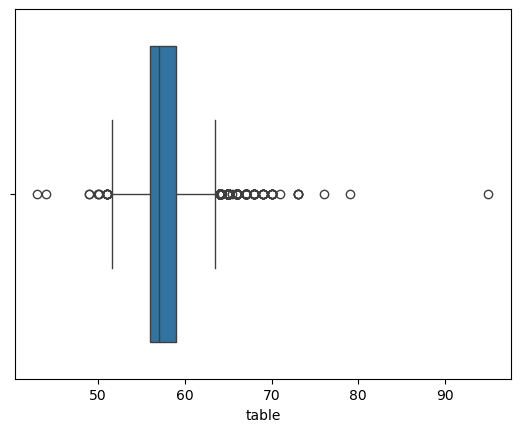

In [4]:
sns.boxplot(x = df_table)

In [5]:
#esik deger belirleme
Q1 = df_table.quantile(0.25)
Q3 = df_table.quantile(0.75)
IQR = (Q3 - Q1) * 1.5

In [6]:
Q1

np.float64(56.0)

In [7]:
Q3

np.float64(59.0)

In [8]:
IQR

np.float64(4.5)

In [9]:
alt_sinir = Q1 - IQR
ust_sinir = Q3 + IQR

In [10]:
alt_sinir

np.float64(51.5)

In [11]:
ust_sinir

np.float64(63.5)

***Q1**, **Q3** ve **IQR** değerlerini bize boxplot grafiği veriyor. Biz de burda el ile hesaplayarak görmüş olduk.*

In [12]:
#aykırı değerlere erişmek
#alt sınırdan küçük olanları veya üst sınırdan büyük olanları tespit etmek
(df_table < alt_sinir) | (df_table > ust_sinir)

0        False
1        False
2         True
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Name: table, Length: 53940, dtype: bool

In [13]:
aykiri_tf = (df_table < alt_sinir)

In [14]:
aykiri_tf.head()

0    False
1    False
2    False
3    False
4    False
Name: table, dtype: bool

In [15]:
# alt sınırdan küçük değerlere ulaşmak
df_table[aykiri_tf]

1515     51.0
3238     50.1
3979     51.0
4150     51.0
5979     49.0
7418     50.0
8853     51.0
11368    43.0
22701    49.0
25179    50.0
26387    51.0
33586    51.0
35633    44.0
45798    51.0
46040    51.0
47630    51.0
Name: table, dtype: float64

In [16]:
aykiri_tf = (df_table > ust_sinir)

In [17]:
aykiri_tf.head()

0    False
1    False
2     True
3    False
4    False
Name: table, dtype: bool

In [18]:
#üst sınırdan büyük değerlere erişmek
df_table[aykiri_tf]

2        65.0
91       69.0
145      64.0
219      64.0
227      67.0
         ... 
53695    65.0
53697    65.0
53756    64.0
53757    64.0
53785    65.0
Name: table, Length: 589, dtype: float64

***aykiri_tf** bir true-false vektörü. df_table'a bu vektörü yollayarak sadece koşulu sağlayan değerleri fancy index ile çekmiş olduk.*

In [19]:
df_table[aykiri_tf].index

Index([    2,    91,   145,   219,   227,   239,   296,   314,   356,   359,
       ...
       53226, 53503, 53542, 53577, 53660, 53695, 53697, 53756, 53757, 53785],
      dtype='int64', length=589)